In [1]:
# NOTE: I know the animation code is clunky and crappy. This isn't production software, just a notebook to make animations
import matplotlib
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\setlength{\jot}{48pt}"
from cycler import cycler
SITE_PALETTE = ["#3366CC", "#DB4325", "#2E8B57", "#9B59B6", "#B85C00", "#0E7C7B"]
matplotlib.rcParams["axes.prop_cycle"] = cycler(color=SITE_PALETTE)
import matplotlib.gridspec as gridspec
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import math

In [2]:




def setup_graph():
    plt.xlim(-1, 8)
    plt.ylim(-1, 2)
    plt.xticks(range(8))
    plt.yticks([0, 1])
    plt.axhline(0,  ls="--")
    plt.axvline(0,  ls="--")

def configure_axes(ax):
    ax.axhline( ls="--", color="0.5")
    ax.axvline( ls="--", color="0.5")
    ax.set_xlim(-2, 5)
    ax.set_ylim(-1, 8)

THEMES = {
    "dark":  {"bg": "#23201c", "panel": "#322d25", "fg": "#e4ddcf", "accent": "#9cbf88"},
    "light": {"bg": "#f5f0e6", "panel": "#ffffff", "fg": "#2e2a24", "accent": "#4a6b3d"},
}

# Save a figure to a file
def save_fig(fig, stem,):
    for name, c in THEMES.items():
        fig.patch.set_facecolor(c["bg"])
        for ax in fig.axes:
            ax.set_facecolor(c["bg"])
            for spine in ax.spines.values():
                spine.set_color(c["fg"])
            ax.tick_params(colors=c["fg"])
            ax.xaxis.label.set_color(c["fg"])
            ax.yaxis.label.set_color(c["fg"])
            ax.title.set_color(c["fg"])
            ax.set_facecolor(c["panel"])
        # COMMENT OUT THIS LINE TO DISABLE SAVING
        fig.savefig(f"{stem}-{name}.png", facecolor=c["bg"], bbox_inches="tight")
    pass

import os
image_folder_name="generated_images"
os.makedirs(image_folder_name, exist_ok=True)

x = 3.5, f(x) = 2.5833333333333335
f'(x) = 1.6666666666666667


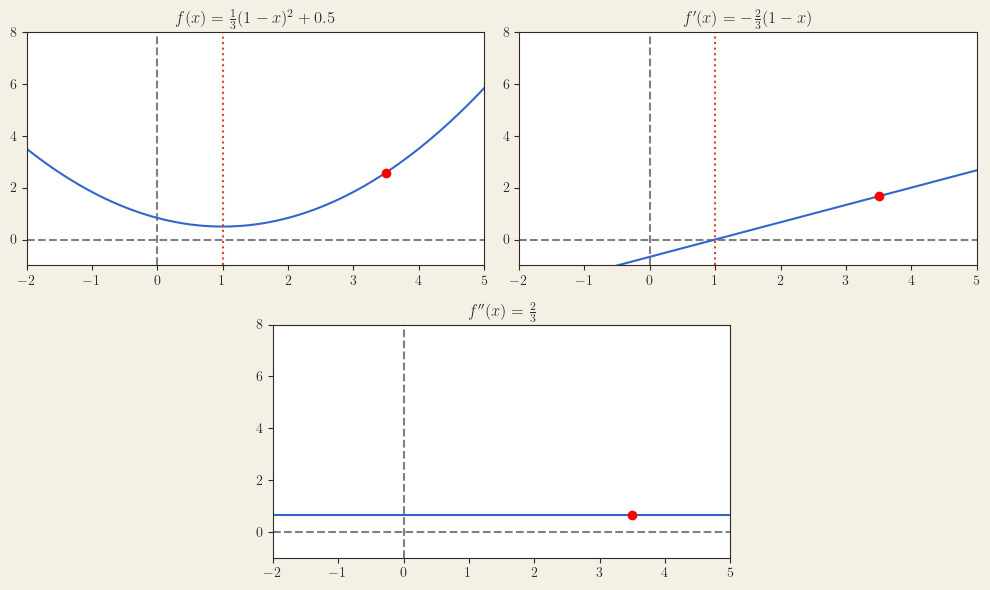

In [3]:
# Simple Quadratic
xs = [x/10 for x in range(-100, 100)]
ys= [((x-1)**2) /3 + 0.5 for x in xs]

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3]) 
configure_axes(ax1)
configure_axes(ax2)
configure_axes(ax3)

ax1.set_title(r"$f(x) = \frac{1}{3}(1-x)^2 + 0.5$")
ax1.plot(xs, ys)
ax1.axvline(1, ls=":", color=SITE_PALETTE[1])
ax1.plot(xs[-65], ys[-65], "ro-")
print(f"x = {xs[-65]}, f(x) = {ys[-65]}")

ax2.set_title(r"$f'(x) = -\frac{2}{3}(1-x)$")
ax2.plot(xs, [2*(x-1)/3 for x in xs])
y_val = 2*(xs[-65]-1)/3
ax2.plot(xs[-65], [y_val], "ro-")
ax2.axvline(1, ls=":", color=SITE_PALETTE[1])
print(f"f'(x) = {y_val}")

ax3.set_title(r"$f''(x) = \frac{2}{3}$")
ax3.plot(xs, [2/3 for _ in xs])
ax3.plot(xs[-65], 2/3, "ro-")
plt.tight_layout()
save_fig(fig, f"{image_folder_name}/simple_quadratic")

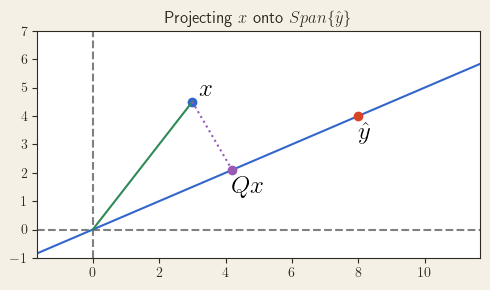

In [4]:
font_size = 18

fig = plt.figure(figsize=(5, 3))

ax = fig.subplots()

configure_axes(ax)
ax.set_xlim(-5/3, 7 * 5/3)
ax.set_ylim(-1, 7)

y_slope = .5

point_y = (8, 4)
line_through_y = ([x for x in (-2, 14)], [x*y_slope for x in (-2, 14)])
ray_to_x = ([x for x in (0,3)], [1.5 * x for x in (0,3)])
point_x = (3, 4.5)
point_Qx = (21/5, 21/10)
projection_line = ([3, 21/5], [-2 * x + 10.5 for x in (3, 21/5)])

ax.plot(*line_through_y)
ax.plot(*point_y, "o-")
ax.annotate(r"$\hat{y}$", (8, 3.2), weight="bold", fontsize=font_size)
ax.plot(*point_x, marker='o', color=SITE_PALETTE[0])
ax.annotate("$x$", (3.2,4.7), weight="bold",fontsize=font_size )
ax.plot(*ray_to_x)
ax.plot(*point_Qx, "o")
ax.annotate("$Qx$", (21/5, 13/10), fontsize=font_size)

ax.plot(*projection_line, ls=":", color=SITE_PALETTE[3])

ax.set_title(r"$\text{Projecting } x \text{ onto } Span \{\hat{y}\}$")

plt.tight_layout()
save_fig(fig, f"{image_folder_name}/project_onto_y_p1")

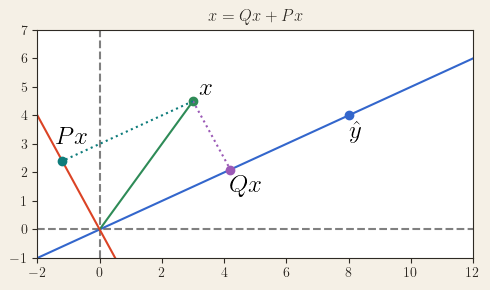

In [5]:
font_size = 18

fig = plt.figure(figsize=(5, 3))

ax = fig.subplots()

configure_axes(ax)
ax.set_xlim(-2, 12)
ax.set_ylim(-1, 7)

y_slope = .5

point_y = (8, 4)
line_through_y = ([x for x in (-2, 14)], [x*y_slope for x in (-2, 14)])
ray_to_x = ([x for x in (0,3)], [1.5 * x for x in (0,3)])
point_x = (3, 4.5)
point_Qx = (21/5, 21/10)
projection_to_y = ([3, 21/5], [-2 * x + 10.5 for x in (3, 21/5)])
y_complement = ([-3,3], [-1 / y_slope * x for x in (-3,3)])
point_z = (-1.2, 2.4)
projection_to_not_y = ([point_x[0], point_z[0]], [point_x[1], point_z[1]])

ax.plot(*line_through_y, color=SITE_PALETTE[0])
ax.plot(*point_y, "o-", color=SITE_PALETTE[0])
ax.annotate(r"$\hat{y}$", (8, 3.2), weight="bold", fontsize=font_size)
ax.plot(*point_x, marker='o', color=SITE_PALETTE[2])
ax.annotate("$x$", (3.2,4.7), weight="bold",fontsize=font_size )
ax.plot(*ray_to_x, color=SITE_PALETTE[2])
ax.plot(*point_Qx, "o", color=SITE_PALETTE[3])
ax.annotate("$Qx$", (21/5, 13/10), fontsize=font_size)

ax.plot(*projection_to_y, ls=":", color=SITE_PALETTE[3])

ax.plot(*y_complement, color=SITE_PALETTE[1])
ax.plot(*point_z, "o", color=SITE_PALETTE[5])
ax.plot(*projection_to_not_y, ls=":", color=SITE_PALETTE[5])
ax.annotate("$Px$", (point_z[0] - 0.2, point_z[1] + 0.6), fontsize=font_size)

ax.set_title(r"$x = Qx + Px$")

plt.tight_layout()
save_fig(fig, f"{image_folder_name}/project_onto_y_p2")

In [11]:
from manim import *
import numpy as np

# Inline preview size in the notebook.
config.media_width = "80%"
config.media_embed = True
config.quality = "high_quality" if os.getenv("CI") else "low_quality"

gradient_color = PURE_RED
newtonian_color = PURE_GREEN
cmap = "viridis"

# Requires pts to be in no more dimensions than the scene
def np_downsample(p, target_samples=300):
    pts = np.array([[r[0], r[1]] for r in p])
    s = np.diff(pts, axis=0) # Take the difference along axis 0, so each new row i is the element-wise difference of pts[i+1] and pts[i]
    s = np.linalg.norm(s, axis=1) # take the norm of each vector, i.e calculate euclidean distance between pts[i] and pts[i+1]
    s = np.cumsum(s) # the i'th element in `s` is now the traced-path distance from pts[0] to pts[i+1]
    s = np.concatenate(([0], s)) # prepend a 0, so now s is the traced-path distance from pts[0] to pts[i]
    targets = np.linspace(0, s[-1], target_samples) # take evenly spaced samples along the path-length traced by pts
    idxs = np.searchsorted(s, targets) # find the indexes of the elements of s with values closest to the values in targets
    idxs = np.clip(idxs, 0, len(pts)-1) # make sure we don't go out of bounds
    return pts[idxs]


weight = 0.15
def modified_easing(t):
    if t < weight:
        return weight * rate_functions.ease_in_quad(t / weight)
    return weight + (1 - weight) * rate_functions.ease_out_cubic((t-(weight)) /(1-weight))

bold_math = TexTemplate()
bold_math.add_to_document(r"\boldmath")

TexTemplate(_body='', tex_compiler='latex', description='', output_format='.dvi', documentclass='\\documentclass[preview]{standalone}', preamble='\\usepackage[english]{babel}\n\\usepackage{amsmath}\n\\usepackage{amssymb}', placeholder_text='YourTextHere', post_doc_commands='\\boldmath')

In [ ]:
%%manim -v WARNING LineSearch

def f(x):
    return (x-2)**2

def f_prime(x):
    return 2*(x - 2)
def f_dprime(x):
    return 2

x = -0.25
starting_point = (x, f(x))
p = -1 * f_prime(x) / f_dprime(x)
print("p", p)

# returns the height of the alpha line
c = 0.1
def alpha_height(a):
    return starting_point[1] + c * a * p * f_prime(x)

print("start", starting_point)
print("alpha 0", alpha_height(0))

class LineSearch(Scene):
    def construct(self):
        line = NumberLine(x_range=[0, 2.5, 0.5], length=10, tick_size=0.25, include_numbers=True, include_tip=True, numbers_to_include=[x for x in range(3)], line_to_number_buff=0.3)
        plane = NumberPlane(x_range=[-5,10], y_range=[-1.5,6])
        mid_spacer = Rectangle(height=1.5).set_opacity(0)
        bot_spacer = Rectangle(height=0.25).set_opacity(0)
        group = VGroup(plane, mid_spacer, line, bot_spacer).arrange(DOWN)
        group.stretch_to_fit_height(config.frame_height)
        self.add(group)

        parabola_plot = plane.plot(f, color=GOLD_A)
        self.add(parabola_plot)


        alpha_value = ValueTracker(0)

        pointer = Vector(DOWN).scale(0.5, scale_tips=False)
        pointer.add_updater(lambda m: m.next_to(line.n2p(alpha_value.get_value()), UP), call_updater=True)
        self.add(pointer)

        alpha_text = MathTex(r"\alpha = ")
        alpha_number = DecimalNumber(alpha_value.get_value(), edge_to_fix=LEFT, num_decimal_places=2)
        alpha_number = alpha_number.add_updater(lambda m: m.set_value(alpha_value.get_value()))
        alpha_label = VGroup(alpha_text, alpha_number).arrange(RIGHT)
        alpha_label.add_updater(lambda m: m.next_to(pointer, UP), call_updater=True)
        self.add(alpha_label)


        def render_alpha_line(a):
            height = alpha_height(a)
            s = [-10, height, 0]
            e = [10, height, 0]
            return Line(start=plane.c2p(s), end=plane.c2p(e), color=RED)

        alpha_line = always_redraw(lambda: render_alpha_line(alpha_value.get_value()))

        alpha_line_text = MathTex(r"f(x_k) + c_1\alpha p_k f'(x_k)", color=RED, tex_template=bold_math).next_to(alpha_line, DOWN).shift(6.8 * RIGHT)

        def render_moving_dot(a):
            x_coord = starting_point[0] + a * p
            y_coord = f(x_coord)
            return Dot(plane.c2p((x_coord, y_coord)), color=GREEN)
        
        moving_dot = always_redraw(lambda: render_moving_dot(alpha_value.get_value()))
        starting_dot = Dot(point=plane.c2p(starting_point))

        dot_label = MathTex(r"f(x_k + \alpha p_k)", color=GREEN, tex_template=bold_math).next_to(moving_dot, 0.9 *LEFT).shift(0.4 * DOWN)
        self.play(Create(starting_dot, run_time=1.5), Create(moving_dot, run_time=1.5), FadeIn(dot_label))
        self.add(dot_label)
        self.wait(2)
        self.play(FadeOut(dot_label))
        


        self.play(Create(alpha_line, run_time=1.5), FadeIn(alpha_line_text))
        self.wait(2)
        self.play(FadeOut(alpha_line_text))
        self.wait()
        # self.play(alpha_value.animate.set_value(3))
        # self.play(alpha_value.animate.set_value(2))
        self.play(alpha_value.animate.set_value(1.80), run_time=4, rate_func=rate_functions.smooth)
        self.wait(2)

        


p 2.25
start (-0.25, 5.0625)
alpha 0 5.0625
max alpha 0.8888888888888888


Manim Community v0.20.1

In [16]:
%%manim -v WARNING -qh GradientVsNewtonian
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...

starting_point = [-0.5, 1.25]

a, b = 1, 50
def surface_function(p):
    x, y = p
    rosenbrock = (a - x)**2 + b*(y-x**2)**2
    return rosenbrock

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.001)

positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=12000

for _ in range(ITERATIONS):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)


print("positions_g final: ", positions_g[-1])
positions_g = [(x, y) for (x, y, _) in positions_g]
positions_g = np_downsample(positions_g)

# print("positions_g len: ", len(positions_g))

p = torch.tensor(starting_point, requires_grad=True)

for _ in range(5):
    gradients = torch.autograd.functional.jacobian(surface_function, p)
    hessian = torch.autograd.functional.hessian(surface_function, p)
    step = torch.linalg.solve(hessian, gradients) # find x that solves for B x = df
    with torch.no_grad():
        p -= step
    record_position(p, positions_n)



# print("graident: ", positions_g[-5:])
print("newtonian: ", positions_n)
# print("newton finite:", np.isfinite(positions_n).all())
# print("grad  finite:", np.isfinite(positions_g).all())
# print(positions_g)
def surface_numpy(x, y):
    return (a - x)**2 + b*(y-x**2)**2


class GradientVsNewtonian(Scene):
    def construct(self):
        x_range = [-1.5, 1.5]
        y_range = [-2, 3]
        axes = Axes(x_range=x_range, y_range=y_range)

        def make_heatmap(res=400):
            xs = np.linspace(x_range[0], x_range[1], res)
            ys = np.linspace(y_range[0], y_range[1], res)
            X, Y = np.meshgrid(xs, ys)
            Z = surface_numpy(X, Y)
            Z = np.log(Z + 1)
            Z = (Z-Z.min()) / (Z.max() - Z.min())
            rgba = (matplotlib.colormaps[cmap](Z, bytes=True))
            rgba = np.flipud(rgba)
            lo, hi = axes.c2p(x_range[0], y_range[0]), axes.c2p(x_range[1], y_range[1])
            img = ImageMobject(rgba)
            img.stretch_to_fit_width(abs(hi[0] - lo[0]))
            img.stretch_to_fit_height(abs(hi[1] - lo[1]))
            img.move_to(axes.c2p(np.mean(x_range), np.mean(y_range)))
            border = SurroundingRectangle(img, color=WHITE, buff=0, stroke_width=1)
            return Group(img, border)
        

        heat = make_heatmap()

        def make_legend(res=256):
            ramp = np.linspace(1, 0, res).reshape(res, 1)
            rgba = matplotlib.colormaps[cmap](ramp, bytes=True)

            bar = ImageMobject(rgba)
            bar.stretch_to_fit_height(heat.height * 0.8)
            bar.stretch_to_fit_width(0.4)
            bar.next_to(heat, RIGHT, buff=0.6)

            border = SurroundingRectangle(bar, color=WHITE, buff=0, stroke_width=1)
            high = Text("High", font_size=22).next_to(bar, UP, buff=0.15)
            low = Text("Low", font_size=22 ).next_to(bar, DOWN, buff=0.15)
            return Group(bar, border, high, low)
        
        legend = make_legend()

        gradient_coords = [axes.c2p(x, y) for (x, y) in positions_g]
        newtonian_coords = [axes.c2p(x, y) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        self.add(heat)
        # self.add(axes)
        self.add(legend)


        minimum = Dot(point=newtonian_coords[-1], color=BLACK, stroke_width=2, stroke_color=WHITE)
        min_text = Text("Minimum", font_size=36, fill_color=BLACK, stroke_color=WHITE, stroke_width=2, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(minimum, run_time=1.5), Create(min_text))
        self.wait()
        self.play(FadeOut(min_text, run_time=0.5))
        self.wait(0.5)

        gd = Dot(point=[gradient_coords[0]], color=gradient_color, stroke_width=1, stroke_color=BLACK)
        gd_text = Text("Gradient Descent", font_size=36, fill_color=gradient_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(gd, run_time=1.5), Create(gd_text))
        self.wait()

        gd_trace = TracedPath(gd.get_center, stroke_color=gradient_color, stroke_width=4)
        self.add(gd_trace)
        self.play(MoveAlongPath(gd, gradient_path, rate_func=modified_easing, run_time=5))

        self.play(FadeOut(gd_text, run_time=0.5))
        self.wait(0.5)

        nd = Dot(point=[newtonian_coords[0]], color=newtonian_color, stroke_width=1, stroke_color=BLACK)
        nd_text = Text("Newtonian Optimization", font_size=36, color=newtonian_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(nd, run_time=1.5), Create(nd_text))
        self.wait()


        self.add(Dot(point=gradient_coords[0], color=newtonian_color, fill_opacity=0.7))
        for i in range(1,len(newtonian_coords)):
            partial_path = VMobject().set_points_as_corners(newtonian_coords[i-1:i+1])
            self.play(MoveAlongPath(nd, partial_path, rate_func=rate_functions.ease_in_out_cubic, run_time=1))
            self.wait(0.5)
            self.add(Dot(point=newtonian_coords[i], color=newtonian_color, fill_opacity=0.7, stroke_width=1, stroke_color=BLACK))
        


        self.wait()

positions_g final:  [0.9966963529586792, 0.993377149105072, 1.0949102033919189e-05]
newtonian:  [[-0.5, 1.25, 52.25], [-0.5151515007019043, 0.2651515603065491, 2.295686721801758], [0.9660125970840454, -1.260666847229004, 240.64942932128906], [0.9661667346954346, 0.9334781169891357, 0.0011446898570284247], [1.0000009536743164, 0.9988572001457214, 6.551772821694613e-05], [1.0000001192092896, 1.000000238418579, 1.4210854715202004e-14]]


Manim Community v0.20.1

In [14]:
%%manim -v WARNING SinusoidalValley
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...

starting_point = [-0.5, 1.0]

a, b = 1, 50
def surface_function(p):
    x, y = p
    return torch.sin(x) + torch.sin(y)

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.001)

positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=12000

for _ in range(ITERATIONS):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)


print("positions_g final: ", positions_g[-1])
positions_g = [(x, y) for (x, y, _) in positions_g]
positions_g = np_downsample(positions_g)

# print("positions_g len: ", len(positions_g))

p = torch.tensor(starting_point, requires_grad=True)

for _ in range(3):
    gradients = torch.autograd.functional.jacobian(surface_function, p)
    hessian = torch.autograd.functional.hessian(surface_function, p)
    step = torch.linalg.solve(hessian, gradients) # find x that solves for B x = df
    with torch.no_grad():
        p -= step
    record_position(p, positions_n)



# print("graident: ", positions_g[-5:])
print("newtonian: ", positions_n)
# print("newton finite:", np.isfinite(positions_n).all())
# print("grad  finite:", np.isfinite(positions_g).all())
# print(positions_g)
def surface_numpy(x, y):
    return np.sin(x) + np.sin(y)


class SinusoidalValley(Scene):
    def construct(self):
        x_range = [-3, 3]
        y_range = [-3, 3]
        axes = Axes(x_range=x_range, y_range=y_range)

        def make_heatmap(res=400):
            xs = np.linspace(x_range[0], x_range[1], res)
            ys = np.linspace(y_range[0], y_range[1], res)
            X, Y = np.meshgrid(xs, ys)
            Z = surface_numpy(X, Y)
            Z = (Z-Z.min()) / (Z.max() - Z.min())
            rgba = (matplotlib.colormaps[cmap](Z, bytes=True))
            rgba = np.flipud(rgba)
            lo, hi = axes.c2p(x_range[0], y_range[0]), axes.c2p(x_range[1], y_range[1])
            img = ImageMobject(rgba)
            img.stretch_to_fit_width(abs(hi[0] - lo[0]))
            img.stretch_to_fit_height(abs(hi[1] - lo[1]))
            img.move_to(axes.c2p(np.mean(x_range), np.mean(y_range)))
            border = SurroundingRectangle(img, color=WHITE, buff=0, stroke_width=1)
            return Group(img, border)
        

        heat = make_heatmap()

        def make_legend(res=256):
            ramp = np.linspace(1, 0, res).reshape(res, 1)
            rgba = matplotlib.colormaps[cmap](ramp, bytes=True)

            bar = ImageMobject(rgba)
            bar.stretch_to_fit_height(heat.height * 0.8)
            bar.stretch_to_fit_width(0.4)
            bar.next_to(heat, RIGHT, buff=0.6)

            border = SurroundingRectangle(bar, color=WHITE, buff=0, stroke_width=1)
            high = Text("High", font_size=22).next_to(bar, UP, buff=0.15)
            low = Text("Low", font_size=22 ).next_to(bar, DOWN, buff=0.15)
            return Group(bar, border, high, low)
        
        legend = make_legend()

        gradient_coords = [axes.c2p(x, y) for (x, y) in positions_g]
        newtonian_coords = [axes.c2p(x, y) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        self.add(heat)
        # self.add(axes)
        self.add(legend)


        minimum = Dot(point=axes.c2p([math.pi * -0.5, math.pi * -0.5]), color=BLACK, stroke_width=2, stroke_color=WHITE)
        min_text = Text("Minimum", font_size=36, fill_color=BLACK, stroke_color=WHITE, stroke_width=2, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(minimum, run_time=1.5), Create(min_text))
        self.wait()
        self.play(FadeOut(min_text, run_time=0.5))
        self.wait(0.5)

        gd = Dot(point=[gradient_coords[0]], color=gradient_color, stroke_width=1, stroke_color=BLACK)
        gd_text = Text("Gradient Descent", font_size=36, fill_color=gradient_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(gd, run_time=1.5), Create(gd_text))
        self.wait()

        gd_trace = TracedPath(gd.get_center, stroke_color=gradient_color, stroke_width=4)
        self.add(gd_trace)
        self.play(MoveAlongPath(gd, gradient_path, rate_func=modified_easing, run_time=5))

        self.play(FadeOut(gd_text, run_time=0.5))
        self.wait(0.5)

        nd = Dot(point=[newtonian_coords[0]], color=newtonian_color, stroke_width=1, stroke_color=BLACK)
        nd_text = Text("Newtonian Optimization", font_size=36, color=newtonian_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(nd, run_time=1.5), Create(nd_text))
        self.wait()


        self.add(Dot(point=gradient_coords[0], color=newtonian_color, fill_opacity=0.7))
        for i in range(1,len(newtonian_coords)):
            partial_path = VMobject().set_points_as_corners(newtonian_coords[i-1:i+1])
            self.play(MoveAlongPath(nd, partial_path, rate_func=rate_functions.ease_in_out_cubic, run_time=1))
            self.wait(0.5)
            self.add(Dot(point=newtonian_coords[i], color=newtonian_color, fill_opacity=0.7, stroke_width=1, stroke_color=BLACK))
        


        self.wait()

positions_g final:  [-1.5707367658615112, -1.5707367658615112, -2.0]
newtonian:  [[-0.5, 1.0, 0.36204540729522705], [-2.3304877281188965, 1.6420927047729492, 0.27241086959838867], [-1.380623459815979, 1.570675253868103, 0.018028438091278076], [-1.573122501373291, 1.5707963705062866, 2.682209014892578e-06]]


Manim Community v0.20.1

In [15]:
%%manim -v WARNING -qh BfgsRosenbrok
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...

starting_point = [-0.5, 1.25]

a, b = 1, 50
def surface_function(p):
    x, y = p
    rosenbrock = (a - x)**2 + b*(y-x**2)**2
    return rosenbrock

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.001)

positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=12000

for _ in range(ITERATIONS):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)


print("positions_g final: ", positions_g[-1])
positions_g = [(x, y) for (x, y, _) in positions_g]
positions_g = np_downsample(positions_g)


def surface_scipy(x):
    return (a - x[0])**2 + b*(x[1]-x[0]**2)**2

r = scipy.optimize.minimize(surface_scipy, starting_point, method="BFGS", options={"return_all": True})
print(r)
positions_n = [[x[0].item(), x[1].item(), surface_scipy(x).item()] for x in r.allvecs[:-3]]



# print("graident: ", positions_g[-5:])
print("newtonian steps: ", len(positions_n))
print("newtonian: ", positions_n)
# print("newton finite:", np.isfinite(positions_n).all())
# print("grad  finite:", np.isfinite(positions_g).all())
# print(positions_g)
def surface_animation(x, y):
    return (a - x)**2 + b*(y-x**2)**2


class BfgsRosenbrok(Scene):
    # ThreeDScene gives you a movable 3D camera. construct() is the "script":
    # everything you add()/play() here becomes the animation, in order.
    def construct(self):
        # ThreeDAxes draws the x/y/z frame. Ranges are [min, max, step].
        x_range = [-1.5, 1.5]
        y_range = [-2, 3]
        axes = Axes(x_range=x_range, y_range=y_range)

        def make_heatmap(res=400):
            xs = np.linspace(x_range[0], x_range[1], res)
            ys = np.linspace(y_range[0], y_range[1], res)
            X, Y = np.meshgrid(xs, ys)
            Z = surface_animation(X, Y)
            Z = np.log(Z + 1)
            Z = (Z-Z.min()) / (Z.max() - Z.min())
            rgba = (matplotlib.colormaps[cmap](Z, bytes=True))
            rgba = np.flipud(rgba)
            lo, hi = axes.c2p(x_range[0], y_range[0]), axes.c2p(x_range[1], y_range[1])
            img = ImageMobject(rgba)
            img.stretch_to_fit_width(abs(hi[0] - lo[0]))
            img.stretch_to_fit_height(abs(hi[1] - lo[1]))
            img.move_to(axes.c2p(np.mean(x_range), np.mean(y_range)))
            border = SurroundingRectangle(img, color=WHITE, buff=0, stroke_width=1)
            return Group(img, border)
        

        heat = make_heatmap()

        def make_legend(res=256):
            ramp = np.linspace(1, 0, res).reshape(res, 1)
            rgba = matplotlib.colormaps[cmap](ramp, bytes=True)

            bar = ImageMobject(rgba)
            bar.stretch_to_fit_height(heat.height * 0.8)
            bar.stretch_to_fit_width(0.4)
            bar.next_to(heat, RIGHT, buff=0.6)

            border = SurroundingRectangle(bar, color=WHITE, buff=0, stroke_width=1)
            high = Text("High", font_size=22).next_to(bar, UP, buff=0.15)
            low = Text("Low", font_size=22 ).next_to(bar, DOWN, buff=0.15)
            return Group(bar, border, high, low)
        
        legend = make_legend()

        gradient_coords = [axes.c2p(x, y) for (x, y) in positions_g]
        newtonian_coords = [axes.c2p(x, y) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        self.add(heat)
        # self.add(axes)
        self.add(legend)


        minimum = Dot(point=newtonian_coords[-1], color=BLACK, stroke_width=2, stroke_color=WHITE)
        min_text = Text("Minimum", font_size=36, fill_color=BLACK, stroke_color=WHITE, stroke_width=2, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(minimum, run_time=1.5), Create(min_text))
        self.wait()
        self.play(FadeOut(min_text, run_time=0.5))
        self.wait(0.5)

        # gd = Dot(point=[gradient_coords[0]], color=gradient_color, stroke_width=1, stroke_color=BLACK)
        # gd_text = Text("Gradient Descent", font_size=36, fill_color=gradient_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        # self.play(Create(gd, run_time=1), Create(gd_text))
        # self.wait()

        # gd_trace = TracedPath(gd.get_center, stroke_color=gradient_color, stroke_width=4)
        # self.add(gd_trace)
        # self.play(MoveAlongPath(gd, gradient_path, rate_func=modified_easing, run_time=2.5))

        # self.play(FadeOut(gd_text, run_time=0.5))
        # self.wait(0.5)

        nd = Dot(point=[newtonian_coords[0]], color=newtonian_color, stroke_width=1, stroke_color=BLACK)
        nd_text = Text("BFGS Optimization", font_size=36, color=newtonian_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(nd, run_time=1.5), Create(nd_text))
        self.wait()


        self.add(Dot(point=gradient_coords[0], color=newtonian_color, fill_opacity=0.7))
        for i in range(1,len(newtonian_coords)):
            partial_path = VMobject().set_points_as_corners(newtonian_coords[i-1:i+1])
            self.play(MoveAlongPath(nd, partial_path, rate_func=rate_functions.ease_in_out_cubic, run_time=.75))
            self.wait(0.1)
            self.add(Dot(point=newtonian_coords[i], color=newtonian_color, fill_opacity=0.7, stroke_width=1, stroke_color=BLACK))
        


        self.wait()

positions_g final:  [0.9966963529586792, 0.993377149105072, 1.0949102033919189e-05]


NameError: name 'scipy' is not defined

In [ ]:
%%manim -v WARNING BfgsSinusoidal
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...

starting_point = [-0.5, 1.0]

a, b = 1, 50
def surface_function(p):
    x, y = p
    return torch.sin(x) + torch.sin(y)

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.001)

positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=12000

for _ in range(ITERATIONS):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)


print("positions_g final: ", positions_g[-1])
positions_g = [(x, y) for (x, y, _) in positions_g]
positions_g = np_downsample(positions_g)

# print("positions_g len: ", len(positions_g))

p = torch.tensor(starting_point, requires_grad=True)

for _ in range(3):
    gradients = torch.autograd.functional.jacobian(surface_function, p)
    hessian = torch.autograd.functional.hessian(surface_function, p)
    step = torch.linalg.solve(hessian, gradients) # find x that solves for B x = df
    with torch.no_grad():
        p -= step
    record_position(p, positions_n)

def surface_scipy(x):
    return math.sin(x[0]) + math.sin(x[1])

r = scipy.optimize.minimize(surface_scipy, starting_point, method="BFGS", options={"return_all": True})
print(r)
positions_n = [[x[0].item(), x[1].item(), surface_scipy(x)] for x in r.allvecs[:-3]]

# print("graident: ", positions_g[-5:])
print("newtonian: ", positions_n)
# print("newton finite:", np.isfinite(positions_n).all())
# print("grad  finite:", np.isfinite(positions_g).all())
# print(positions_g)
def surface_numpy(x, y):
    return np.sin(x) + np.sin(y)


class BfgsSinusoidal(Scene):
    # ThreeDScene gives you a movable 3D camera. construct() is the "script":
    # everything you add()/play() here becomes the animation, in order.
    def construct(self):
        # ThreeDAxes draws the x/y/z frame. Ranges are [min, max, step].
        x_range = [-3, 3]
        y_range = [-3, 3]
        axes = Axes(x_range=x_range, y_range=y_range)

        def make_heatmap(res=400):
            xs = np.linspace(x_range[0], x_range[1], res)
            ys = np.linspace(y_range[0], y_range[1], res)
            X, Y = np.meshgrid(xs, ys)
            Z = surface_numpy(X, Y)
            Z = (Z-Z.min()) / (Z.max() - Z.min())
            rgba = (matplotlib.colormaps[cmap](Z, bytes=True))
            rgba = np.flipud(rgba)
            lo, hi = axes.c2p(x_range[0], y_range[0]), axes.c2p(x_range[1], y_range[1])
            img = ImageMobject(rgba)
            img.stretch_to_fit_width(abs(hi[0] - lo[0]))
            img.stretch_to_fit_height(abs(hi[1] - lo[1]))
            img.move_to(axes.c2p(np.mean(x_range), np.mean(y_range)))
            border = SurroundingRectangle(img, color=WHITE, buff=0, stroke_width=1)
            return Group(img, border)
        

        heat = make_heatmap()

        def make_legend(res=256):
            ramp = np.linspace(1, 0, res).reshape(res, 1)
            rgba = matplotlib.colormaps[cmap](ramp, bytes=True)

            bar = ImageMobject(rgba)
            bar.stretch_to_fit_height(heat.height * 0.8)
            bar.stretch_to_fit_width(0.4)
            bar.next_to(heat, RIGHT, buff=0.6)

            border = SurroundingRectangle(bar, color=WHITE, buff=0, stroke_width=1)
            high = Text("High", font_size=22).next_to(bar, UP, buff=0.15)
            low = Text("Low", font_size=22 ).next_to(bar, DOWN, buff=0.15)
            return Group(bar, border, high, low)
        
        legend = make_legend()

        gradient_coords = [axes.c2p(x, y) for (x, y) in positions_g]
        newtonian_coords = [axes.c2p(x, y) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        self.add(heat)
        # self.add(axes)
        self.add(legend)


        minimum = Dot(point=axes.c2p([math.pi * -0.5, math.pi * -0.5]), color=BLACK, stroke_width=2, stroke_color=WHITE)
        min_text = Text("Minimum", font_size=36, fill_color=BLACK, stroke_color=WHITE, stroke_width=2, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(minimum, run_time=1.5), Create(min_text))
        self.wait()
        self.play(FadeOut(min_text, run_time=0.5))
        self.wait(0.5)

        gd = Dot(point=[gradient_coords[0]], color=gradient_color, stroke_width=1, stroke_color=BLACK)
        gd_text = Text("Gradient Descent", font_size=36, fill_color=gradient_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(gd, run_time=1.5), Create(gd_text))
        self.wait()

        gd_trace = TracedPath(gd.get_center, stroke_color=gradient_color, stroke_width=4)
        self.add(gd_trace)
        self.play(MoveAlongPath(gd, gradient_path, rate_func=modified_easing, run_time=5))

        self.play(FadeOut(gd_text, run_time=0.5))
        self.wait(0.5)

        nd = Dot(point=[newtonian_coords[0]], color=newtonian_color, stroke_width=1, stroke_color=BLACK)
        nd_text = Text("BFGS Optimization", font_size=36, color=newtonian_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(nd, run_time=1.5), Create(nd_text))
        self.wait()


        self.add(Dot(point=gradient_coords[0], color=newtonian_color, fill_opacity=0.7))
        for i in range(1,len(newtonian_coords)):
            partial_path = VMobject().set_points_as_corners(newtonian_coords[i-1:i+1])
            self.play(MoveAlongPath(nd, partial_path, rate_func=rate_functions.ease_in_out_cubic, run_time=1))
            self.wait(0.5)
            self.add(Dot(point=newtonian_coords[i], color=newtonian_color, fill_opacity=0.7, stroke_width=1, stroke_color=BLACK))
        


        self.wait()

positions_g final:  [-1.5707367658615112, -1.5707367658615112, -2.0]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.999999999999986
        x: [-1.571e+00 -1.571e+00]
      nit: 9
      jac: [ 1.490e-07  1.043e-07]
 hess_inv: [[ 1.018e+00  1.117e-02]
            [ 1.117e-02  1.007e+00]]
     nfev: 30
     njev: 10
  allvecs: [array([-5.000e-01,  1.000e+00]), array([-1.360e+00,  4.705e-01]), array([-2.678e+00, -1.230e+00]), array([-2.172e+00, -1.138e+00]), array([-1.348e+00, -1.678e+00]), array([-1.585e+00, -1.577e+00]), array([-1.569e+00, -1.567e+00]), array([-1.571e+00, -1.571e+00]), array([-1.571e+00, -1.571e+00]), array([-1.571e+00, -1.571e+00])]
newtonian:  [[-0.5, 1.0, 0.3620454462036935], [-1.360064869068828, 0.4704828416438048, -0.5245614546271823], [-2.677726344727503, -1.229550392166748, -1.3897476266818884], [-2.1717749753894298, -1.1376351452758433, -1.7324260391195228], [-1.3484136426252713, -1.677587632566253, -1.969677932991842

Manim Community v0.20.1